In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

from LoadStockData import LoadStockData
# 包含資產特徵
from TCNDQN_Environment import Environment
from TCNDQN_DQNAgent import DQNAgent
# from TCNDQN_DQNAgent_1 import DQNAgent

  

# training hyper-parameters
batch_size = 32  # 設定批次大小
sliding_window = 60
const = 10

train_start_date = 20000101  # 設定訓練起始日期
# 盤整
train_end_date = 20240930  # 設定訓練結束日期
# 上漲
train_end_date = 20201231  # 設定訓練結束日期
# 下跌
train_end_date = 20220331  # 設定訓練結束日期
# 2025
train_end_date = 20241231  # 設定訓練結束日期

season = "2021-1"  # 設定季度，格式為 YYYY-Q (例如 "2021-1" 表示 2021 年第一季度)

# 根據季度設定 train_end_date
if season == "2021-1":
    train_end_date = 20201231
elif season == "2021-2":
    train_end_date = 20210331
elif season == "2021-3":
    train_end_date = 20210630
elif season == "2021-4":
    train_end_date = 20210930
elif season == "2022-1":
    train_end_date = 20211231
elif season == "2022-2":
    train_end_date = 20220331
elif season == "2022-3":
    train_end_date = 20220630
elif season == "2022-4":
    train_end_date = 20220930
elif season == "2023-1":
    train_end_date = 20221231
elif season == "2023-2":
    train_end_date = 20230331
elif season == "2023-3":
    train_end_date = 20230630
elif season == "2023-4":
    train_end_date = 20230930
elif season == "2024-1":
    train_end_date = 20231231
elif season == "2024-2":
    train_end_date = 20240331
elif season == "2024-3":
    train_end_date = 20240630
elif season == "2024-4":
    train_end_date = 20240930
else:
    train_end_date = 20201231  # 預設值


data_start_date = train_start_date - 20000  # 設定資料起始日期
data_end_date = train_end_date + 9100       # 設定資料結束日期

trend = "" # 設定趨勢類型，分別為下跌、上漲和盤整
num = 0

action_type = ["sell","hold","buy"] # 設定動作類型
field_names = ["close","change"]
cost_names = ["avgcost","Total cost"]
# TCN hyper-parameters
tcn_window = 256  # TCN 的時間窗口大小   
layer_channels = [12, 12, 12, 12, 12, 12, 12]  # 7 層
kernel_size = 3
# tcn_window = 128  # TCN 的時間窗口大小   
# layer_channels = [8, 8, 8, 8, 8, 8]  # 6 層
# kernel_size = 3
# tcn_window = 70  # TCN 的時間窗口大小   
# layer_channels = [8, 8, 8, 8, 8]  # TCN 每層的通道數量
# kernel_size = 3
# layer_channels = [8, 8, 8, 8]   # TCN 每層的通道數量
# kernel_size = 5

# check the device
device = ("cuda" if torch.cuda.is_available() else "cpu")
# print(device)
# exit()

    
    

./model/2021-1/


In [2]:
if season == "":
    path = f"./model/{trend}_trend/{num}/"
else:
    path = f"./model/{season}/"
Path(path).mkdir(parents=True, exist_ok=True)  # 如果資料夾不存在則創建
# 繪製 Action Distribution 圖表
def plot_action_distribution(action_distribution_history, n_episodes, action_type):
    action_distribution_history = np.array(action_distribution_history)
    x = np.arange(1, n_episodes + 1)

    plt.figure(figsize=(12, 6))
    for i, label in enumerate(action_type):
        plt.plot(x, action_distribution_history[:, i], label=label)

    plt.xlabel('Episode', fontsize=14)
    plt.ylabel('Action Distribution', fontsize=14)
    plt.title('Action Distribution Over Episodes', fontsize=16)
    plt.legend(fontsize=12)
    plt.grid()
    plt.savefig(f"{path}/Action_Distribution.png")
    plt.show()

> adding stock market: S&P_500 
> adding stock market: Dow_Jones 
> adding stock market: NASDAQ 
> adding stock market: PHLX 
> adding stock market: N225 
> adding stock market: FTSE 
> adding stock market: FCHI 
> adding stock market: DAX 
> adding stock market: 000001.SS 


100%|██████████| 5165/5165 [03:55<00:00, 21.91it/s]


Episode 1, Action distribution: [0.35159729 0.31810261 0.3303001 ]
Episode 1/100, Total Loss:146630.1912, Avg. Loss:28.3892, Epsilon: 0.8573, Total Reward: -51919.1562


100%|██████████| 5165/5165 [03:58<00:00, 21.66it/s]


Episode 2, Action distribution: [0.3231365  0.32758955 0.34927396]
Episode 2/100, Total Loss:177136.2106, Avg. Loss:34.2955, Epsilon: 0.7342, Total Reward: -42580.3594


...

Episode 98, Action distribution: [0.27473379 0.33146176 0.39380445]
Episode 98/100, Total Loss:214050.1511, Avg. Loss:41.4424, Epsilon: 0.0100, Total Reward: 76933.5938


100%|██████████| 5165/5165 [04:50<00:00, 17.80it/s]


Episode 99, Action distribution: [0.2607938  0.35082285 0.38838335]
Episode 99/100, Total Loss:211103.9722, Avg. Loss:40.8720, Epsilon: 0.0100, Total Reward: 70797.1172


100%|██████████| 5165/5165 [04:51<00:00, 17.72it/s]


Episode 100, Action distribution: [0.26776379 0.37463698 0.35759923]
Episode 100/100, Total Loss:197453.5291, Avg. Loss:38.2291, Epsilon: 0.0100, Total Reward: 72864.5547

Q-Value Statistics Summary:
Predict Q Mean (Avg): 307.7506, Std (Avg): 250.6747
Target Q Mean (Avg): 310.0115, Std (Avg): 257.0611


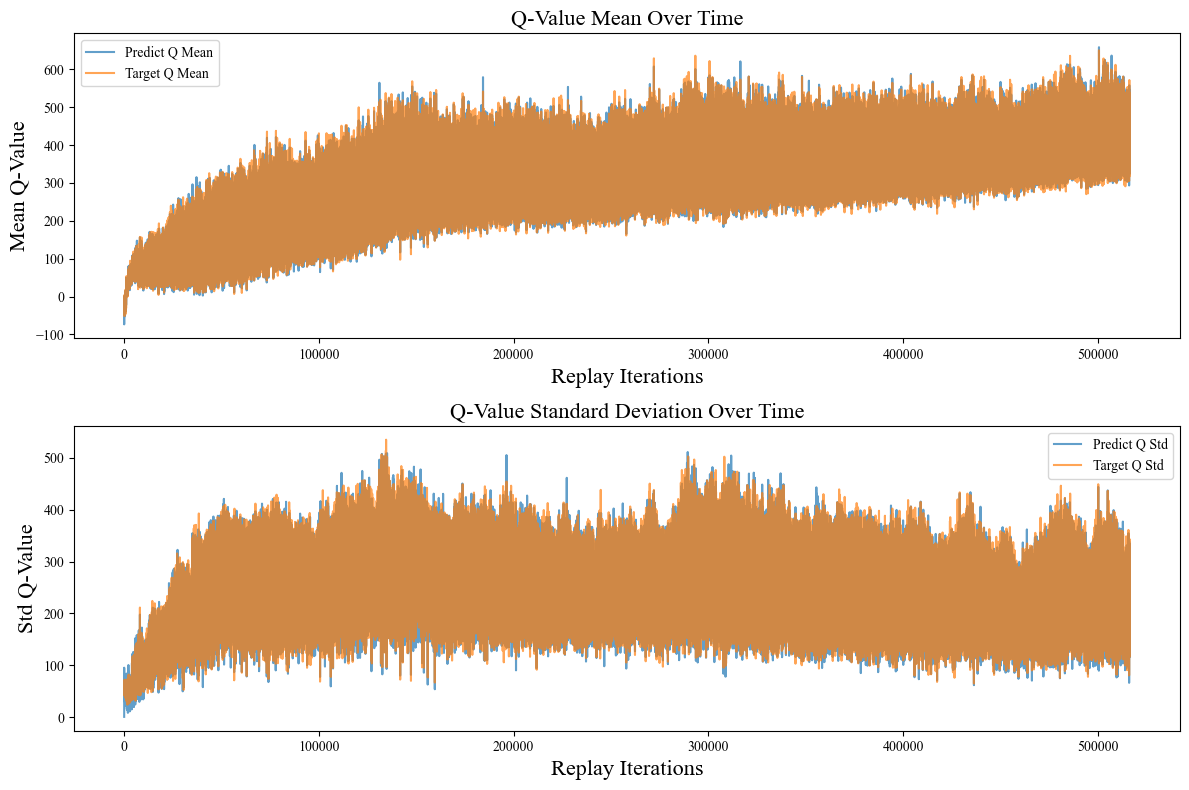

In [3]:
# load data
aux_market_names = [
    "S&P_500",
    "Dow_Jones",
    "NASDAQ",
    "PHLX",
    "N225",
    "FTSE",
    "FCHI",
    "DAX",
    "000001.SS",
]
filename = "StockData/TWII.csv"
data_period = (data_start_date, data_end_date) 
Stock_Data = LoadStockData("TWII", field_names, filename, data_period)
Stock_Data.AddNewData(
    aux_market_names,
    [
        "StockData/S&P_500.csv",
        "StockData/Dow_Jones.csv",
        "StockData/NASDAQ.csv",
        "StockData/PHLX.csv",
        "StockData/N225.csv",
        "StockData/FTSE.csv",
        "StockData/FCHI.csv",
        "StockData/DAX.csv",
        "StockData/000001.SS.csv",
    ],
)

# get the prices of all stock markets
selected_market_names = ["TWII"] + aux_market_names
# selected_market_names = ["TWII"] 
dates, prices = Stock_Data.get_prices(data_period, field_names, selected_market_names)
if len(field_names) < 2:
    prices = np.squeeze(prices, axis=1)
# print(dates)
# exit()

# 將資料轉換為 torch tensor
prices = torch.FloatTensor(prices)
# print(f"price shape:{prices.shape}")
# exit()


# 設定模型
price_size = len(selected_market_names)  # TCN 輸出的股價狀態維度
cost_size = len(cost_names)  # TCN 輸出的成本狀態維度

# 包含資產特徵
agent = DQNAgent(price_size, cost_size, layer_channels, kernel_size, action_size=len(action_type), device=device, batch_size = batch_size, output_dir=path)
# 初始化環境
env = Environment(prices, dates, start_date=train_start_date, end_date=train_end_date, tcn_window=tcn_window, sliding_window=sliding_window, const = const, device=device)


# 輸出從 startdate 開始的步驟
# print(f"Start step for {start_date}, index:{env.start_step}")

# 開始訓練
loss_history, reward_history, action_distribution_history = agent.train(env)

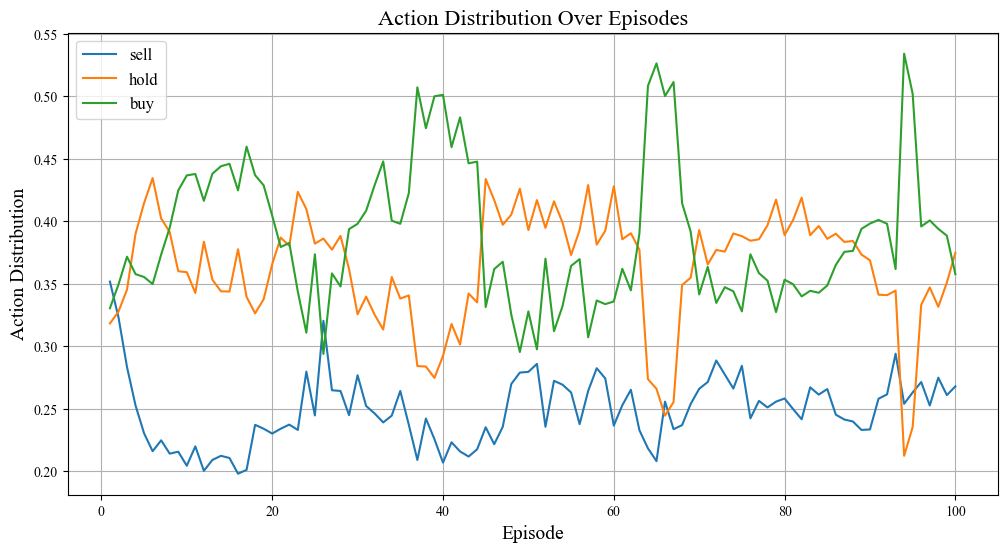

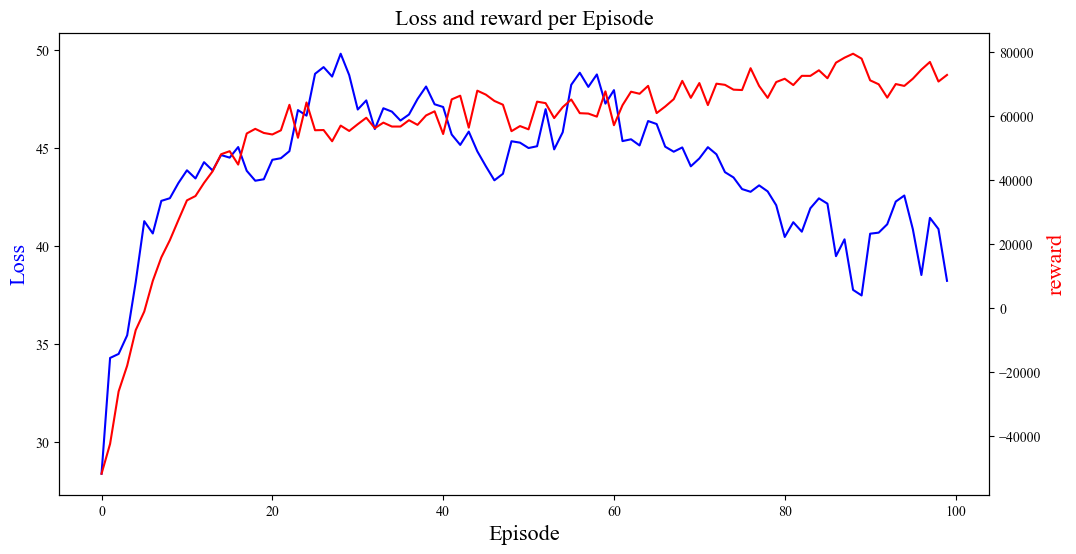

In [4]:
# 繪製動作分布圖
plot_action_distribution(action_distribution_history, n_episodes=100, action_type=action_type)

# 建立 x 軸資料
x = range(len(loss_history))
# 建立兩條線的 y 軸資料
y1 = [loss for loss in loss_history]
y2 = [reward for reward in reward_history]

# 設置字體為 Times New Roman
plt.rcParams["font.family"] = "Times New Roman"

# 建立主圖表
fig, ax1 = plt.subplots(figsize=(12, 6))

# 繪製第一條線並設置左側的 y 軸標籤
ax1.plot(x, y1, "-b", label="Loss")
ax1.set_xlabel("Episode", fontsize=16)
ax1.set_ylabel("Loss", color="blue", fontsize=16)
# 創建共享 x 軸的第二個 y 軸
ax2 = ax1.twinx()

# 繪製第二條線並設置右側的 y 軸標籤
ax2.plot(x, y2, "-r", label="reward")
ax2.set_ylabel("reward", color="red", fontsize=16)

plt.title("Loss and reward per Episode", fontsize=16)
plt.savefig(f"{path}{season}.png")
plt.show()